In [4]:
!pip install torch torchaudio transformers datasets librosa sounddevice scipy

In [5]:
!pip install scikit-learn jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.7 MB/s eta 0:00:00


In [6]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 14.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 7.6 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=fe4ad537ea25384489806f9a2680467bc51b547949fa967eba4954527f259060
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [7]:
!pip install pyttsx3

In [8]:
import os
import pandas as pd
import numpy as np
import torch
import librosa

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from jiwer import wer

In [9]:
!pip install kagglehub

In [10]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("him0005/historical-ohlc-and-volume-data")

print("Dataset path:", path)

100%|██████████| 385k/385k [00:00<00:00, 1.01MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/him0005/historical-ohlc-and-volume-data/versions/1


In [11]:
import os
os.listdir(path)

['combined_ohlc.csv']

In [12]:
# Load OHLCV
import pandas as pd
import numpy as np

# Replace filename if needed
file_path = path + '/combined_ohlc.csv'

df = pd.read_csv(file_path)

df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2015-01-02,AAPL,24.694225,24.705311,23.798591,24.237541,212818400.0
1,2015-01-05,AAPL,24.006994,24.086803,23.368523,23.554743,257142000.0
2,2015-01-06,AAPL,23.619033,23.816338,23.195601,23.556959,263188400.0
3,2015-01-07,AAPL,23.765345,23.987036,23.654499,23.887276,160423600.0
4,2015-01-08,AAPL,24.215383,24.862723,24.097885,24.805082,237458000.0


In [13]:
# sort by date;
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [14]:
# handle missing dates/outliers
df = df.fillna(method='ffill')

/tmp/ipykernel_1126/1427358252.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [15]:
df['next_close'] = df['Close'].shift(-1)

In [16]:
df['next_return'] = df['Close'].pct_change().shift(-1)

In [17]:
df = df.dropna()

In [18]:
# scale features (MinMax)
from sklearn.preprocessing import MinMaxScaler

features = ['Open', 'High', 'Low', 'Close', 'Volume']
target = 'next_close'   # or 'next_return'

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features, index=df.index)

In [19]:
# create sequences (sliding window)
def create_sequences(data, target_data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(target_data[i])
    return np.array(X), np.array(y)

window_size = 60

X, y = create_sequences(
    scaled_df.values,
    df[target].values,
    window_size
)

print(X.shape, y.shape)

(11264, 60, 5) (11264,)


In [20]:
# time-aware train/test split
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [21]:
# train LSTM/GRU; predict
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 46s 134ms/step - loss: 9473.2266 - val_loss: 29675.0449
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 7465.1733 - val_loss: 25408.5781
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - loss: 6276.9097 - val_loss: 22249.6426
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - loss: 5442.1929 - val_loss: 19936.1250
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - loss: 5209.4204 - val_loss: 18304.2090
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 27s 97ms/step - loss: 4722.6294 - val_loss: 17225.6660
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 4954.4038 - val_loss: 16589.7422
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - loss: 4881.6445 - val_loss: 16224.8311
Epoch 9/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 4860.4800 - val_loss: 16037.2832
Epoch 10/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - loss: 4860.1582 - val_loss: 15960.4531
Epoch 11/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 77m

In [23]:
y_pred = model.predict(X_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


In [24]:
# evaluate (MAE/RMSE)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 114.19288933589307
RMSE: 136.10130378824235


In [25]:
# evaluate (directional accuracy)
direction_true = np.sign(y_test[1:] - y_test[:-1])
direction_pred = np.sign(y_pred[1:] - y_pred[:-1].flatten())

directional_accuracy = np.mean(direction_true == direction_pred)

print("Directional Accuracy:", directional_accuracy)

Directional Accuracy: 0.48523357173729925


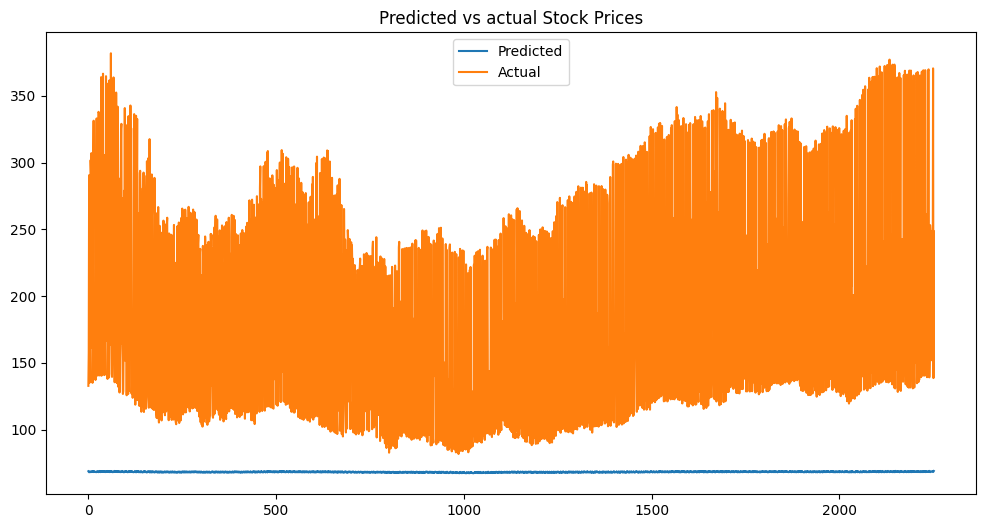

In [29]:
# plot predicted vs actual
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_pred, label="Predicted")
plt.plot(y_test, label="Actual")
plt.legend()
plt.title("Predicted vs actual Stock Prices")
plt.show()